In [12]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [7]:


# includes all elections outs
directory = "../results/preflib-resampling/oracle-and-bootstrap"

pickle_files = []
for filename in os.listdir(directory):
    file_path = os.path.join(directory, filename)
    if os.path.isfile(file_path):
        pickle_files.append(file_path)

len(pickle_files)

165

[0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64, 0.95, 1.0]
ers-05-0.38760000000000006
ers-16-0.68
ers-19-0.6736
ers-27-0.6516000000000001
ers-52-0.5212
ers-86-0.7744000000000001
glasgow-04-0.7695000000000001
glasgow-09-0.7810000000000001
glasgow-12-0.758
glasgow-17-0.6209999999999999
glasgow-20-0.624


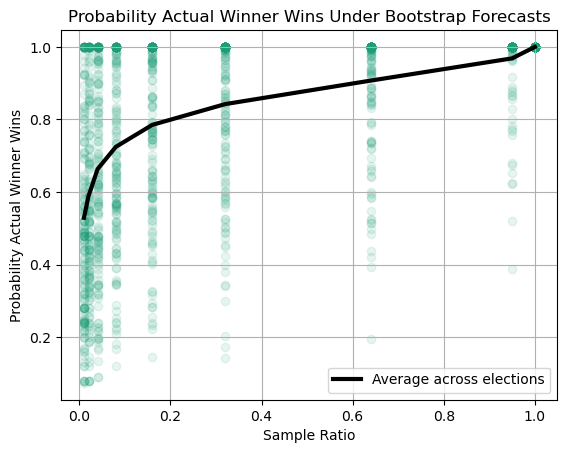

In [29]:
fig, ax = plt.subplots()

means_by_rate = {}
for file_idx, file_path in enumerate(pickle_files):
    with open(file_path, "rb") as pickle_file:
        bootstrap_results = pickle.load(pickle_file)

        assert "sampling_rates" in bootstrap_results and len(bootstrap_results["sampling_rates"]) > 0
        num_ratios = len(bootstrap_results["sampling_rates"])
        assert "oracle_means" in bootstrap_results and len(bootstrap_results["oracle_means"]) == num_ratios

        ax.scatter(
            bootstrap_results["sampling_rates"],
            bootstrap_results["oracle_means"],
            alpha=0.1,
            color="#1b9e77"
        )
        
        if file_idx == 0:
            print(bootstrap_results["sampling_rates"])
            means_by_rate = {rate: [] for rate in bootstrap_results["sampling_rates"]}

        for rate_idx, rate in enumerate(bootstrap_results["sampling_rates"]):
            means_by_rate[rate].append(bootstrap_results["oracle_means"][rate_idx])

        # for analysis only
        if bootstrap_results["oracle_means"][-2] < 0.8:
            print(f"{bootstrap_results['fig_name']}-{bootstrap_results['oracle_means'][-2]}")
ax.plot(
    list(means_by_rate.keys()),
    [np.mean(means_by_rate[rate]) for rate in means_by_rate],
    label="Average across elections",
    color="black",
    linewidth=3
)
ax.set_title("Probability Actual Winner Wins Under Bootstrap Forecasts")
ax.set_xlabel("Sample Ratio")
ax.set_ylabel("Probability Actual Winner Wins")
ax.legend()
ax.grid()

[0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64, 0.95, 1.0]
109


Text(0.5, 1.0, 'Bootstrap')

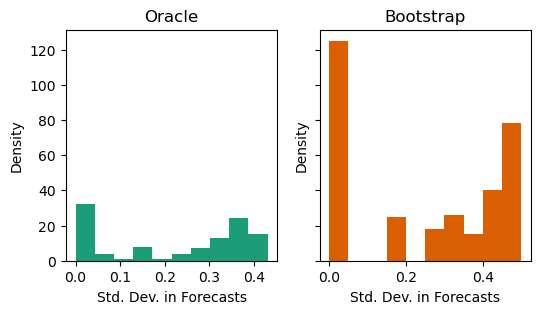

In [47]:
fig, ax = plt.subplots(figsize=(6,3), ncols=2, sharey=True)

sampling_rates = []
oracle_stds = []
bootstrap_stds = []

for file_idx, file_path in enumerate(pickle_files):
    with open(file_path, "rb") as pickle_file:
        bootstrap_results = pickle.load(pickle_file)

        assert "sampling_rates" in bootstrap_results and len(bootstrap_results["sampling_rates"]) > 0
        num_ratios = len(bootstrap_results["sampling_rates"])
        assert "oracle_stds" in bootstrap_results
        assert "forecaster_stds" in bootstrap_results

        if len(bootstrap_results["forecaster_stds"]["Bootstrap"][0]) == 0:
            continue
            
        if sampling_rates == []:
            print(bootstrap_results["sampling_rates"])
            sampling_rates = bootstrap_results["sampling_rates"]

        oracle_stds.append(bootstrap_results["oracle_stds"][4])
        bootstrap_stds.extend(bootstrap_results["forecaster_stds"]["Bootstrap"][4])

print(len(oracle_stds))

ax[0].hist(oracle_stds, bins=10, color="#1b9e77")
ax[0].set_xlabel("Std. Dev. in Forecasts")
ax[0].set_ylabel("Density")
ax[0].set_title("Oracle")

ax[1].hist(bootstrap_stds, bins=10, color="#d95f02")
ax[1].set_xlabel("Std. Dev. in Forecasts")
ax[1].set_ylabel("Density")
ax[1].set_title("Bootstrap")

# ax[0].set_yscale("log")
# ax[1].set_yscale("log")